In [1]:
from plot_calibration import plot_calibration
import numpy as np
import matplotlib.pyplot as plt
from sklearn.calibration import calibration_curve
from scipy.stats import binomtest
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binomtest
sns.set(style="whitegrid", font_scale=1.7)

Brier COMPASS: 0.2124647061805311
Brier TMB: 0.24130938189303405
Brier PD-L1: 0.41097560975609754


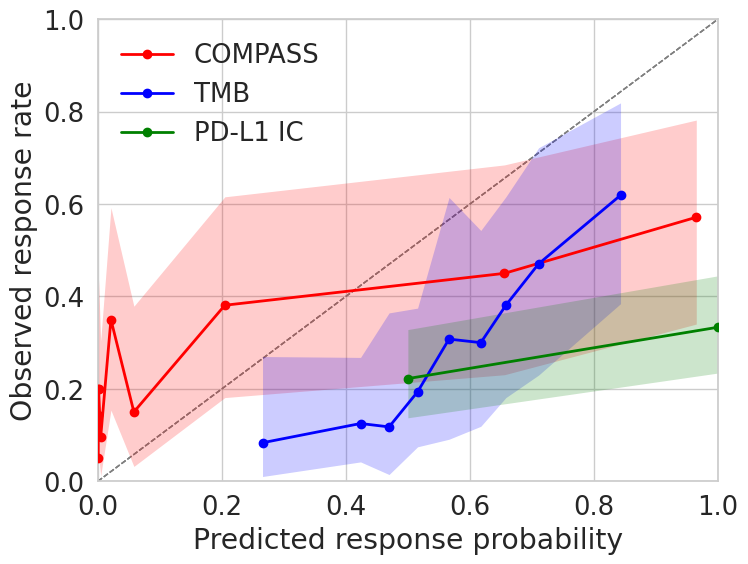

In [2]:

df = pd.read_pickle('./IMvigor210_meta_TMB_IHC_COMPASS_data.pkl')
y_true = pd.get_dummies(df.response_label)['R']
compass_score = df.compass_R_prob
tmb_score = np.log(df.TMB+1)/np.log(df.TMB+1).max()
pdl1_score = df.PDL1.map({'IC0':0, 'IC1':0.5, 'IC2+':1 })

# calibration

fig, ax = plt.subplots(figsize=(8,6))

plot_calibration(y_true, compass_score, label="COMPASS", color="red", ax=ax)
plot_calibration(y_true, tmb_score, label="TMB", color="blue", ax=ax)
plot_calibration(y_true, pdl1_score, label="PD-L1 IC", color="green", ax=ax)

# Brier
from sklearn.metrics import brier_score_loss
print("Brier COMPASS:", brier_score_loss(y_true, compass_score))
print("Brier TMB:", brier_score_loss(y_true, tmb_score))
print("Brier PD-L1:", brier_score_loss(y_true, pdl1_score))
fig.savefig('./alibration.svg', bbox_inches = 'tight' )
# DCA（下一步）

The calibration curve of TMB lay predominantly below the ideal diagonal line, indicating that predicted scores were generally higher than the corresponding observed response rates. This behavior likely reflects the fact that TMB serves as a coarse surrogate of immunogenicity rather than a calibrated probabilistic predictor.

In [3]:
def net_benefit(y_true, y_score, thresholds):
    """
    y_true: binary array (0/1)
    y_score: predicted score or probability
    thresholds: array of threshold probabilities
    """
    y_true = np.asarray(y_true).astype(int)
    y_score = np.asarray(y_score)

    N = len(y_true)
    nb = []

    for pt in thresholds:
        pred = (y_score >= pt).astype(int)

        TP = np.sum((pred == 1) & (y_true == 1))
        FP = np.sum((pred == 1) & (y_true == 0))

        nb_pt = (TP / N) - (FP / N) * (pt / (1 - pt))
        nb.append(nb_pt)

    return np.array(nb)

In [4]:
thresholds = np.linspace(0.05, 0.8, 50)

nb_compass = net_benefit(y_true, compass_score, thresholds)
nb_tmb = net_benefit(y_true, tmb_score, thresholds)
nb_pdl1 = net_benefit(y_true, pdl1_score, thresholds)

# treat-all
prevalence = y_true.mean()
nb_all = prevalence - (1 - prevalence) * (thresholds / (1 - thresholds))

# treat-none
nb_none = np.zeros_like(thresholds)


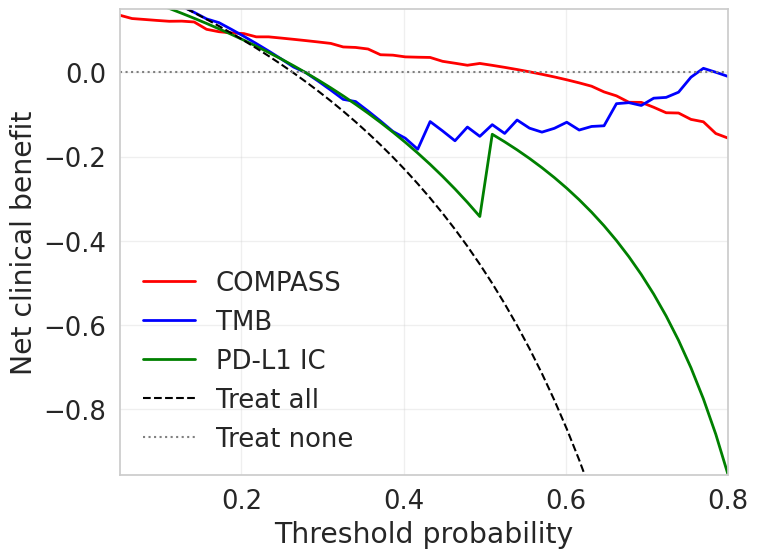

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))

ax.plot(thresholds, nb_compass, label="COMPASS", color="red", lw=2)
ax.plot(thresholds, nb_tmb, label="TMB", color="blue", lw=2)
ax.plot(thresholds, nb_pdl1, label="PD-L1 IC", color="green", lw=2)

ax.plot(thresholds, nb_all, label="Treat all", color="black", ls="--")
ax.plot(thresholds, nb_none, label="Treat none", color="gray", ls=":")

ax.set_xlabel("Threshold probability")
ax.set_ylabel("Net clinical benefit")

ax.set_xlim(0.05, 0.8)
ax.set_ylim(min(nb_pdl1.min(), -0.05), max(nb_compass.max(), 0.15))

ax.legend(frameon=False)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
fig.savefig('./dca.svg', bbox_inches = 'tight' )


Decision-curve analysis showed that COMPASS provided comparable or slightly higher net benefit than TMB across a range of clinically relevant threshold probabilities, while both methods outperformed PD-L1 IC. The non-monotonic pattern observed for TMB in the decision-curve analysis reflects the threshold-dependent trade-off between true- and false-positive selections. At intermediate thresholds, a substantial number of false positives reduce net benefit, whereas at higher thresholds only a small subset of high-TMB patients is selected, among whom response rates are relatively enriched, leading to a partial recovery of net benefit. This behavior is characteristic of single-feature biomarkers with skewed score distributions and does not indicate model instability.